In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [3]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-13 20:58:59 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-13 20:59:00 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-13 20:59:00 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-13 20:59:00 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-13 20:59:01 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-13 20:59:01 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-13 20:59:01 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-13 20:59:01 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows

In [5]:
import os
import torch
torch.set_num_threads(os.cpu_count())

from src.models.lstm import LSTMForecaster
from src.training.trainer import train_model, predict

lstm_model = LSTMForecaster(num_features=X_train.shape[2])
history = train_model(lstm_model, X_train, y_train_scaled, X_val, y_val_scaled, epochs=10)

print("Retrained. Parameters:", history["num_parameters"], "| Time:", round(history["training_time_seconds"], 1), "s")

2026-09-13 21:00:47 | INFO     | src.training.trainer | Training LSTMForecaster | 23576 parameters | device=cpu
2026-09-13 21:00:47 | INFO     | src.training.trainer |   batch 0/131
2026-09-13 21:03:42 | INFO     | src.training.trainer |   batch 100/131
2026-09-13 21:04:13 | INFO     | src.training.trainer | Epoch 1/10 | train_loss=0.053602 | val_loss=0.016427
2026-09-13 21:04:13 | INFO     | src.training.trainer |   batch 0/131
2026-09-13 21:04:48 | INFO     | src.training.trainer |   batch 100/131
2026-09-13 21:05:05 | INFO     | src.training.trainer | Epoch 2/10 | train_loss=0.007219 | val_loss=0.006829
2026-09-13 21:05:05 | INFO     | src.training.trainer |   batch 0/131
2026-09-13 21:05:40 | INFO     | src.training.trainer |   batch 100/131
2026-09-13 21:05:55 | INFO     | src.training.trainer | Epoch 3/10 | train_loss=0.004221 | val_loss=0.004817
2026-09-13 21:05:55 | INFO     | src.training.trainer |   batch 0/131
2026-09-13 21:06:29 | INFO     | src.training.trainer |   batch 1

In [6]:
from src.preprocessing import inverse_transform_column
from src.config import TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON
from src.evaluation.error_analysis import error_by_segment
import numpy as np

y_pred_test_scaled = predict(lstm_model, X_test)
y_true_full = inverse_transform_column(y_test_scaled, scaler, scale_columns, TARGET_COL)
y_pred_full = inverse_transform_column(y_pred_test_scaled, scaler, scale_columns, TARGET_COL)

y_true_h1 = y_true_full[:, 0]
y_pred_h1 = y_pred_full[:, 0]

# Each sequence i's hour+1 target corresponds to row (i + DEFAULT_LOOKBACK) of splits.test
target_row_indices = np.arange(len(y_true_h1)) + DEFAULT_LOOKBACK
segment_info = splits.test.iloc[target_row_indices].reset_index(drop=True)

print("Segment info shape:", segment_info.shape)
print("Matches prediction count:", len(segment_info) == len(y_true_h1))
# Sanity check: the target values should match what's in the original dataframe
print("Sanity check (should be ~0):", np.abs(segment_info[TARGET_COL].values - y_true_h1).max())

Segment info shape: (7087, 41)
Matches prediction count: True
Sanity check (should be ~0): 7.395637021545554e-05


In [7]:
result_weekend = error_by_segment(segment_info, y_true_h1, y_pred_h1, "is_weekend")
print("Weekday(0) vs Weekend(1):")
print(result_weekend)

Weekday(0) vs Weekend(1):
   is_weekend        MAE       RMSE  count
0           0  69.158298  94.451486   5071
1           1  58.507716  75.686212   2016


In [8]:
result_holiday = error_by_segment(segment_info, y_true_h1, y_pred_h1, "holiday")
print("Normal(0) vs Holiday(1):")
print(result_holiday)

Normal(0) vs Holiday(1):
   holiday        MAE       RMSE  count
0        0  66.528734  90.317058   6559
1        1  61.157804  78.869713    528


In [9]:
segment_info["demand_period"] = "other"
segment_info.loc[segment_info["hour"].between(11, 14), "demand_period"] = "peak (11-14h)"
segment_info.loc[segment_info["hour"].between(3, 6), "demand_period"] = "trough (3-6h)"

result_period = error_by_segment(segment_info, y_true_h1, y_pred_h1, "demand_period")
print(result_period)

   demand_period        MAE        RMSE  count
0          other  62.846510   83.249771   4727
1  peak (11-14h)  95.348146  128.266092   1180
2  trough (3-6h)  50.056794   62.525242   1180


In [10]:
result_month = error_by_segment(segment_info, y_true_h1, y_pred_h1, "month")
print(result_month.sort_values("month"))

   month         MAE        RMSE  count
0      1   48.445451   65.886713    744
1      2   48.653058   67.250062    696
2      3   67.259171   95.035491    744
3      4  119.211450  143.715957    720
4      5  112.234054  132.687321    744
5      6   91.291415  107.682314    602
6      9   41.588235   53.012986    629
7     10   38.804276   48.714627    744
8     11   44.674668   56.062130    720
9     12   50.026295   62.900046    744


In [11]:
# Use original (unscaled) temperature data from df_clean/df_features stage, not
# the scaled splits.test — rebuild a quick reference for readability

import pandas as pd

temp_reference = df_features.loc[splits.test.index, "temp_avg"].reset_index(drop=True)
segment_info["temp_avg_unscaled"] = temp_reference.iloc[target_row_indices].values

segment_info["temp_bin"] = pd.qcut(segment_info["temp_avg_unscaled"], q=4, labels=["Coolest 25%", "Cool-mid 25%", "Warm-mid 25%", "Warmest 25%"])

result_temp = error_by_segment(segment_info, y_true_h1, y_pred_h1, "temp_bin")
print(result_temp)

       temp_bin         MAE        RMSE  count
0   Coolest 25%   41.077237   52.182070   1772
1  Cool-mid 25%   57.240896   70.069662   1772
2  Warm-mid 25%   65.246149   84.096875   1771
3   Warmest 25%  100.949562  131.704117   1772


c:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\src\evaluation\error_analysis.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = temp.groupby(segment_column).agg(


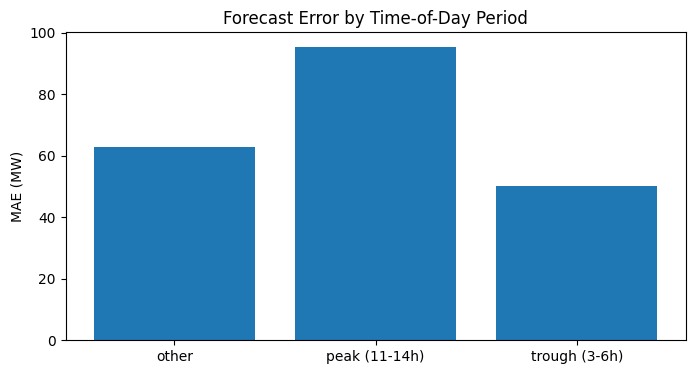

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(result_period["demand_period"], result_period["MAE"])
ax.set_ylabel("MAE (MW)")
ax.set_title("Forecast Error by Time-of-Day Period")
plt.show()

In [13]:
import pandas as pd

with pd.ExcelWriter(Path.cwd().parent / "experiments" / "error_analysis_breakdown.xlsx") as writer:
    result_weekend.to_excel(writer, sheet_name="weekend", index=False)
    result_holiday.to_excel(writer, sheet_name="holiday", index=False)
    result_period.to_excel(writer, sheet_name="peak_trough", index=False)
    result_month.to_excel(writer, sheet_name="month", index=False)
    result_temp.to_excel(writer, sheet_name="temperature", index=False)

print("Saved error_analysis_breakdown.xlsx with all 5 segment breakdowns")

Saved error_analysis_breakdown.xlsx with all 5 segment breakdowns


In [14]:
from src.evaluation.error_analysis import permutation_feature_importance
from src.training.trainer import predict
from src.config import MODEL_FEATURE_COLUMNS

importance_df = permutation_feature_importance(
    lstm_model, X_test, y_test_scaled, MODEL_FEATURE_COLUMNS, predict, n_repeats=3
)
print(importance_df.to_string())

             feature  baseline_mse  permuted_mse  importance
0           hour_sin      0.006026      0.012762    0.006736
1           hour_cos      0.006026      0.011014    0.004987
2            dow_cos      0.006026      0.009213    0.003187
3            dow_sin      0.006026      0.008835    0.002808
4    rolling_mean_24      0.006026      0.007913    0.001887
5         is_weekend      0.006026      0.007797    0.001770
6   rolling_mean_168      0.006026      0.007748    0.001721
7            holiday      0.006026      0.007019    0.000992
8              lag_1      0.006026      0.007007    0.000980
9             lag_48      0.006026      0.006230    0.000204
10        precip_avg      0.006026      0.006190    0.000164
11          temp_avg      0.006026      0.006173    0.000147
12           lag_168      0.006026      0.006103    0.000076
13      humidity_avg      0.006026      0.006033    0.000007
14          wind_avg      0.006026      0.006014   -0.000012
15         month_sin    

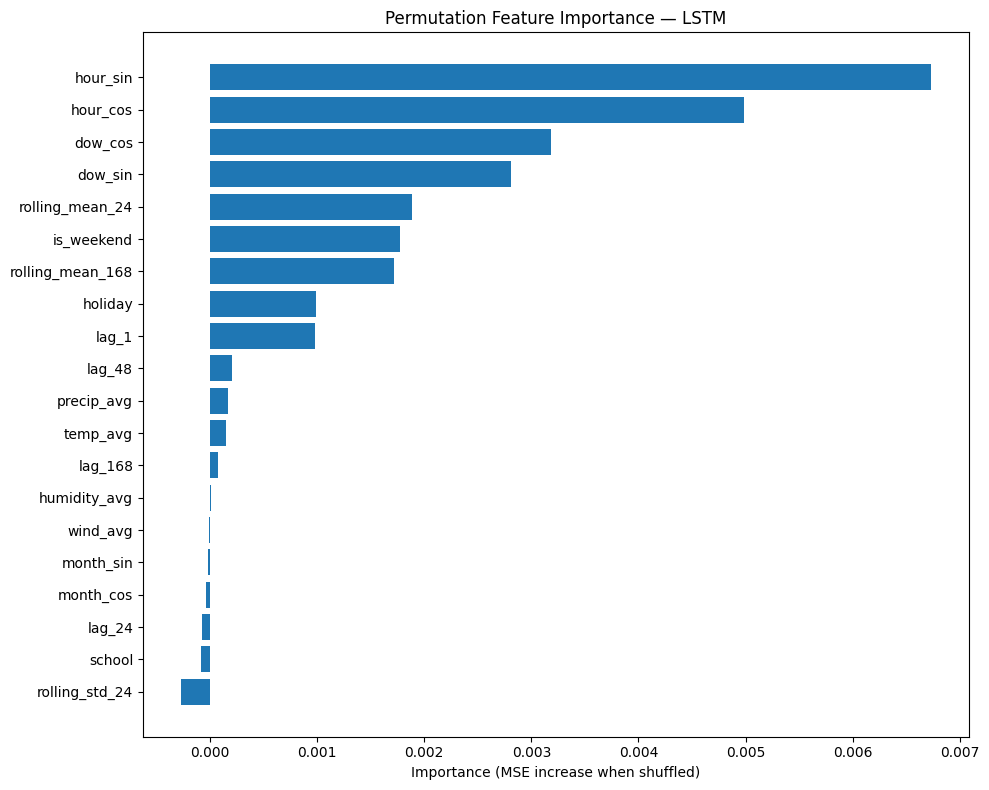

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df["feature"], importance_df["importance"])
ax.set_xlabel("Importance (MSE increase when shuffled)")
ax.set_title("Permutation Feature Importance — LSTM")
ax.invert_yaxis()  # highest importance at top
plt.tight_layout()
plt.show()

In [16]:
importance_df.to_csv(Path.cwd().parent / "experiments" / "permutation_importance.csv", index=False)
print("Saved permutation_importance.csv")


Saved permutation_importance.csv
